In [2]:
!pip install -q kaggle timm albumentations opencv-python matplotlib scikit-learn
!pip install -q grad-cam


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

The syntax of the command is incorrect.
'cp' is not recognized as an internal or external command,
operable program or batch file.
'chmod' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
!kaggle datasets download -d manjilkarki/deepfake-and-real-images -p /content/data --unzip

^C


In [5]:
import os, glob
import pandas as pd
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from pytorch_grad_cam.utils.image import show_cam_on_image

In [6]:
root = "/content/data/Dataset"

train_dir = f"{root}/Train"
val_dir   = f"{root}/Validation"
test_dir  = f"{root}/Test"

print("Train folders:", os.listdir(train_dir))
print("Val folders:", os.listdir(val_dir))
print("Test folders:", os.listdir(test_dir))

print("Train real:", len(os.listdir(f"{train_dir}/Real")))
print("Train fake:", len(os.listdir(f"{train_dir}/Fake")))

Train folders: ['Fake', 'Real']
Val folders: ['Fake', 'Real']
Test folders: ['Fake', 'Real']
Train real: 70001
Train fake: 70001


In [7]:

IMG_EXT = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")

root = "/content/data/Dataset"
train_dir = f"{root}/Train"
val_dir   = f"{root}/Validation"
test_dir  = f"{root}/Test"

def pick_subfolder(base, options):
    for name in options:
        p = os.path.join(base, name)
        if os.path.isdir(p):
            return p
    return None

def list_images(folder):
    files = []
    for ext in IMG_EXT:
        files += glob.glob(os.path.join(folder, ext))
    return files

def make_df(split_dir):
    real_dir = pick_subfolder(split_dir, ["real", "Real", "REAL"])
    fake_dir = pick_subfolder(split_dir, ["fake", "Fake", "FAKE"])

    if real_dir is None or fake_dir is None:
        raise FileNotFoundError(f"Inside {split_dir}, expected real/fake folders but not found.")

    real_files = list_images(real_dir)
    fake_files = list_images(fake_dir)

    df = pd.DataFrame({
        "path": real_files + fake_files,
        "label": [0]*len(real_files) + [1]*len(fake_files)
    }).sample(frac=1, random_state=42).reset_index(drop=True)

    return df

train_df = make_df(train_dir)
val_df   = make_df(val_dir)
test_df  = make_df(test_dir)

print("Train:", train_df["label"].value_counts().to_dict(), "Total:", len(train_df))
print("Val:", val_df["label"].value_counts().to_dict(), "Total:", len(val_df))
print("Test:", test_df["label"].value_counts().to_dict(), "Total:", len(test_df))

Train: {1: 70001, 0: 70001} Total: 140002
Val: {0: 19787, 1: 19641} Total: 39428
Test: {1: 5492, 0: 5413} Total: 10905


In [8]:

def fractal_map(gray, patch=16):
    h, w = gray.shape
    H = (h // patch) * patch
    W = (w // patch) * patch
    gray = gray[:H, :W]

    out = np.zeros((H, W), dtype=np.float32)
    thresholds = [64, 96, 128, 160, 192]

    for y in range(0, H, patch):
        for x in range(0, W, patch):
            p = gray[y:y+patch, x:x+patch]
            counts = []
            for t in thresholds:
                bw = (p > t).astype(np.uint8)
                counts.append(bw.sum())
            score = np.std(counts) / (patch*patch + 1e-6)
            out[y:y+patch, x:x+patch] = score

    out = out - out.min()
    out = out / (out.max() + 1e-6)
    return out

img = cv2.imread("/content/data/Dataset/Test/Fake/fake_0.jpg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
fmap = fractal_map(gray)

print("Fractal Map Shape:", fmap.shape)
print("Fractal Values:")
print(fmap)

Fractal Map Shape: (256, 256)
Fractal Values:
[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.04302339 0.04302339 0.04302339]
 [0.         0.         0.         ... 0.04302339 0.04302339 0.04302339]
 [0.         0.         0.         ... 0.04302339 0.04302339 0.04302339]]


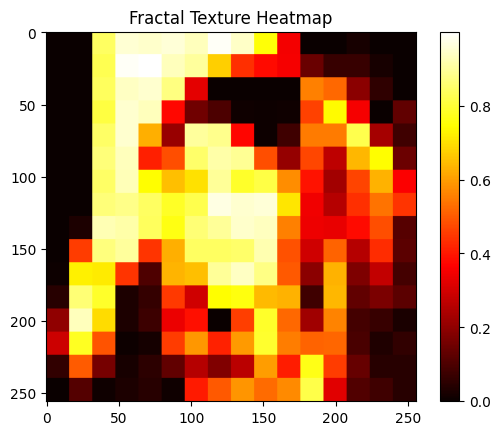

In [9]:
plt.imshow(fmap, cmap="hot")
plt.title("Fractal Texture Heatmap")
plt.colorbar()
plt.show()

In [10]:

IMG_SIZE = 224

train_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.10, rotate_limit=10, p=0.5),
    A.GaussianBlur(p=0.15),
    A.ImageCompression(quality_range=(40, 100), p=0.3),
    A.Normalize(),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

class DeepfakeDataset(Dataset):
    def __init__(self, dataframe, tfms):
        self.df = dataframe.reset_index(drop=True)
        self.tfms = tfms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = self.df.loc[idx, "path"]
        label = int(self.df.loc[idx, "label"])

        bgr = cv2.imread(path)
        bgr = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        gray = cv2.cvtColor(bgr, cv2.COLOR_RGB2GRAY)
        f_map = fractal_map(gray, patch=16)      # 0..1
        f_map = (f_map * 255).astype(np.uint8)   # 0..255
        f_map = np.expand_dims(f_map, axis=2)    # H,W,1

        img4 = np.concatenate([bgr, f_map], axis=2)  # H,W,4

        aug = self.tfms(image=img4)
        x = aug["image"]  # [4,H,W]
        y = torch.tensor(label, dtype=torch.long)

        return x, y, path

BATCH_SIZE = 32
train_loader = DataLoader(DeepfakeDataset(train_df, train_tfms), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(DeepfakeDataset(val_df, val_tfms),     batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(DeepfakeDataset(test_df, val_tfms),    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [11]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = timm.create_model("convnext_tiny", pretrained=True, num_classes=2)

old_conv = model.stem[0]
new_conv = nn.Conv2d(
    in_channels=4,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=old_conv.bias is not None
)

with torch.no_grad():
    new_conv.weight[:, :3, :, :] = old_conv.weight
    new_conv.weight[:, 3:4, :, :] = old_conv.weight.mean(dim=1, keepdim=True)

model.stem[0] = new_conv
model = model.to(device)

print("Model ready ")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Model ready 


In [ ]:

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
scaler = GradScaler(enabled=(device=="cuda"))

EPOCHS = 5
best_val_acc = 0.0
best_path = "/content/best_convnext_fractal.pth"

for epoch in range(EPOCHS):
    # TRAIN
    model.train()
    train_preds, train_true = [], []
    train_loss_sum = 0.0

    for x, y, _ in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=(device=="cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss_sum += loss.item() * x.size(0)
        train_preds += torch.argmax(logits, dim=1).detach().cpu().tolist()
        train_true  += y.detach().cpu().tolist()

    train_loss = train_loss_sum / len(train_true)
    train_acc  = accuracy_score(train_true, train_preds)
    train_f1   = f1_score(train_true, train_preds)

    # VAL
    model.eval()
    val_preds, val_true = [], []
    val_loss_sum = 0.0

    with torch.no_grad():
        for x, y, _ in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            val_loss_sum += loss.item() * x.size(0)
            val_preds += torch.argmax(logits, dim=1).cpu().tolist()
            val_true  += y.cpu().tolist()

    val_loss = val_loss_sum / len(val_true)
    val_acc  = accuracy_score(val_true, val_preds)
    val_f1   = f1_score(val_true, val_preds)

    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} | TrainAcc {train_acc:.4f} F1 {train_f1:.4f} | ValAcc {val_acc:.4f} F1 {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path)
        print(" Saved best:", best_path, "ValAcc:", best_val_acc)

/tmp/ipython-input-1943/3069477540.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(device=="cuda"))
/tmp/ipython-input-1943/3069477540.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device=="cuda")):


Epoch 1/5 | TrainAcc 0.8134 F1 0.8098 | ValAcc 0.9366 F1 0.9366
✅ Saved best: /content/best_convnext_fractal.pth ValAcc: 0.9366440093334686


/tmp/ipython-input-1943/3069477540.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device=="cuda")):


Epoch 2/5 | TrainAcc 0.9505 F1 0.9503 | ValAcc 0.9597 F1 0.9591
✅ Saved best: /content/best_convnext_fractal.pth ValAcc: 0.9597494166582125


/tmp/ipython-input-1943/3069477540.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device=="cuda")):


Epoch 3/5 | TrainAcc 0.9633 F1 0.9632 | ValAcc 0.9549 F1 0.9537


/tmp/ipython-input-1943/3069477540.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device=="cuda")):


Epoch 4/5 | TrainAcc 0.9706 F1 0.9704 | ValAcc 0.9720 F1 0.9718
✅ Saved best: /content/best_convnext_fractal.pth ValAcc: 0.9719742315106016


/tmp/ipython-input-1943/3069477540.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(device=="cuda")):


Epoch 5/5 | TrainAcc 0.9760 F1 0.9759 | ValAcc 0.9766 F1 0.9765
✅ Saved best: /content/best_convnext_fractal.pth ValAcc: 0.976615603124683


In [1]:

model.load_state_dict(torch.load('/content/best_convnext_fractal (3).pth', map_location=device))
model.eval()

test_preds, test_true = [], []
with torch.no_grad():
    for x, y, _ in test_loader:
        x = x.to(device)
        logits = model(x)
        test_preds += torch.argmax(logits, dim=1).cpu().tolist()
        test_true  += y.tolist()

print("Confusion Matrix:\n", confusion_matrix(test_true, test_preds))
print("\nReport:\n", classification_report(test_true, test_preds, target_names=["Real","Fake"]))

NameError: name 'model' is not defined

Train: {1: 70001, 0: 70001} Total: 140002
Val: {0: 19787, 1: 19641} Total: 39428
Test: {1: 5492, 0: 5413} Total: 10905


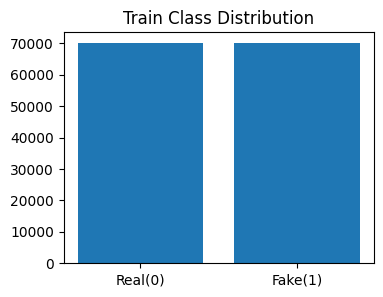

Corrupted (None) images in sample: 0
H range: (256, 256)
W range: (256, 256)


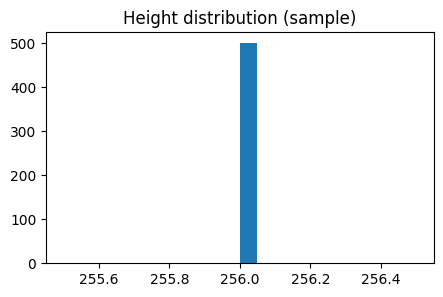

In [13]:

print("Train:", train_df["label"].value_counts().to_dict(), "Total:", len(train_df))
print("Val:", val_df["label"].value_counts().to_dict(), "Total:", len(val_df))
print("Test:", test_df["label"].value_counts().to_dict(), "Total:", len(test_df))


counts = train_df["label"].value_counts().sort_index()
plt.figure(figsize=(4,3))
plt.bar(["Real(0)", "Fake(1)"], counts.values)
plt.title("Train Class Distribution")
plt.show()

hs, ws = [], []
bad = 0
for p in train_df["path"].sample(min(500, len(train_df)), random_state=0):
    im = cv2.imread(p)
    if im is None:
        bad += 1
        continue
    h, w = im.shape[:2]
    hs.append(h); ws.append(w)

print("Corrupted (None) images in sample:", bad)
print("H range:", (min(hs), max(hs)) if hs else None)
print("W range:", (min(ws), max(ws)) if ws else None)

plt.figure(figsize=(5,3))
plt.hist(hs, bins=20)
plt.title("Height distribution (sample)")
plt.show()

In [14]:
real_images_list = []
fake_images_list = []

real_path = "/content/data/Dataset/Test/Real"   # change to your dataset path
fake_path = "/content/data/Dataset/Test/Fake"

# Load real images
for file in os.listdir(real_path):
    img = cv2.imread(os.path.join(real_path, file))
    if img is not None:
        real_images_list.append(img)

# Load fake images
for file in os.listdir(fake_path):
    img = cv2.imread(os.path.join(fake_path, file))
    if img is not None:
        fake_images_list.append(img)

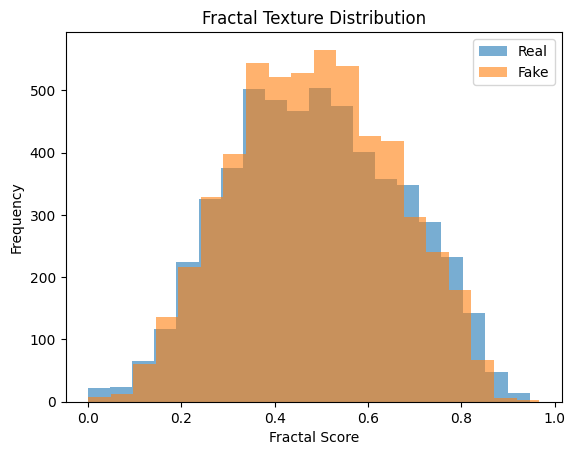

In [15]:
real_scores = []
fake_scores = []

for img in real_images_list:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    fmap = fractal_map(gray)
    real_scores.append(fmap.mean())

for img in fake_images_list:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    fmap = fractal_map(gray)
    fake_scores.append(fmap.mean())

plt.figure()
plt.hist(real_scores, bins=20, alpha=0.6, label="Real")
plt.hist(fake_scores, bins=20, alpha=0.6, label="Fake")
plt.legend()
plt.title("Fractal Texture Distribution")
plt.xlabel("Fractal Score")
plt.ylabel("Frequency")
plt.show()

/tmp/ipykernel_284/752901434.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([real_pixels, fake_pixels], labels=["Real","Fake"])


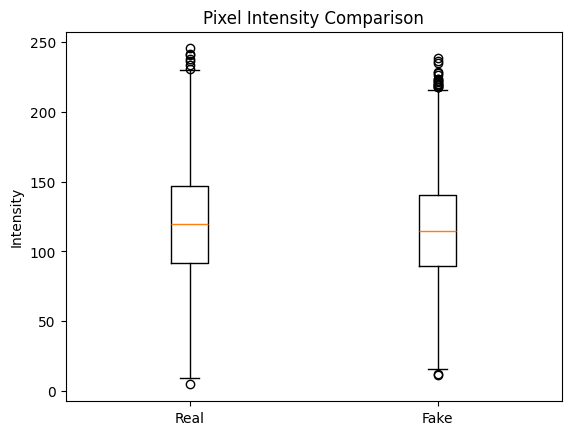

In [16]:
import numpy as np

real_pixels = []
fake_pixels = []

for img in real_images_list:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    real_pixels.append(np.mean(gray))

for img in fake_images_list:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    fake_pixels.append(np.mean(gray))

plt.boxplot([real_pixels, fake_pixels], labels=["Real","Fake"])
plt.title("Pixel Intensity Comparison")
plt.ylabel("Intensity")
plt.show()

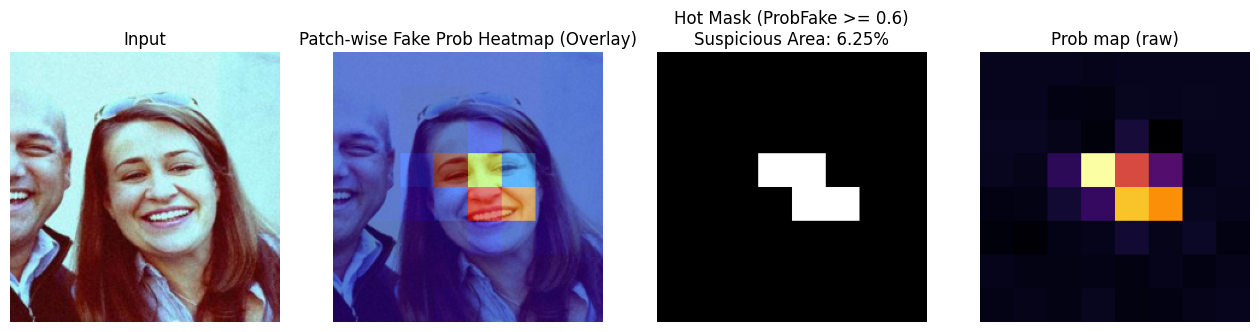

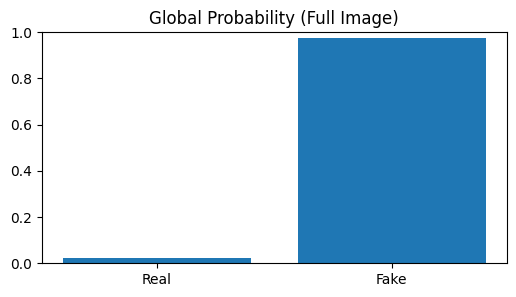

Prediction: Fake
Prob Real: 0.024771172553300858 | Prob Fake: 0.9752287864685059
Suspicious Area %: 6.25
Saved: outputs/fake_1271_prob_overlay.png outputs/fake_1271_hot_mask.png
{'prediction': 'Fake', 'prob_real': 0.024771172553300858, 'prob_fake': 0.9752287864685059, 'suspicious_area_percent': 6.25, 'overlay_path': 'outputs/fake_1271_prob_overlay.png', 'mask_path': 'outputs/fake_1271_hot_mask.png'}


In [23]:

# -----------------------------
# REQUIRED ALREADY:
# model, device, IMG_SIZE, val_tfms, fractal_map(gray, patch=16)
# -----------------------------
model.eval()

def _ensure_dir(d):
    if d and (not os.path.exists(d)):
        os.makedirs(d, exist_ok=True)

def _build_4ch_input(rgb, patch=16):
    """RGB (H,W,3) -> (H,W,4) by adding fractal map channel (resized to match)."""
    H, W = rgb.shape[:2]

    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

    f_map = fractal_map(gray, patch=patch)  # may return smaller map
    f_map = np.nan_to_num(f_map, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    # normalize to 0..1
    fmin, fmax = float(f_map.min()), float(f_map.max())
    if fmax > fmin:
        f_map_norm = (f_map - fmin) / (fmax - fmin)
    else:
        f_map_norm = np.zeros_like(f_map, dtype=np.float32)

    # ✅ Resize fractal map to exactly (H,W)
    if f_map_norm.shape[0] != H or f_map_norm.shape[1] != W:
        f_map_norm = cv2.resize(f_map_norm, (W, H), interpolation=cv2.INTER_LINEAR)

    f_u8 = (f_map_norm * 255).astype(np.uint8)
    f_u8 = f_u8[:, :, None]  # (H,W,1)

    img4 = np.concatenate([rgb, f_u8], axis=2)  # (H,W,4)
    return img4

@torch.no_grad()
def _predict_prob_fake(img4):
    """img4: (H,W,4) uint8 -> returns (prob_real, prob_fake)."""
    aug = val_tfms(image=img4)
    x = aug["image"].unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()
    return float(probs[0]), float(probs[1])

def detect_deepfake_best_localization(
    img_path: str,
    patch_for_fractal: int = 16,
    grid: int = 8,                 # 8 => 8x8 patches (64 calls); 12 => 144 calls (more precise)
    stride: int = None,            # if None -> uses patch size (non-overlapping)
    thr: float = 0.60,             # threshold on fake-prob heatmap for suspicious area
    fake_class_index: int = 1,
    save_dir: str = "outputs",
    show_plots: bool = True,
):
    """
    BEST practical approach without pixel-level masks:
    - Global prediction
    - Patch-wise fake probability heatmap (localization)
    - Suspicious area % based on threshold

    Returns dict for frontend.
    Saves:
      *_prob_overlay.png, *_hot_mask.png
    """

    _ensure_dir(save_dir)

    bgr = cv2.imread(img_path)
    if bgr is None:
        raise FileNotFoundError(f"Could not read image at path: {img_path}")

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb_resized = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

    # -------- Global prediction on full image --------
    img4_full = _build_4ch_input(rgb, patch=patch_for_fractal)
    prob_real, prob_fake = _predict_prob_fake(img4_full)

    pred = int(prob_fake >= prob_real)  # simple
    label = "Fake" if pred == fake_class_index else "Real"

    # If REAL => no suspicious area (as you want)
    if label == "Real":
        hot = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
        overlay = rgb_resized.copy()
        percent = 0.0

        base = os.path.splitext(os.path.basename(img_path))[0]
        overlay_path = os.path.join(save_dir, f"{base}_prob_overlay.png")
        mask_path = os.path.join(save_dir, f"{base}_hot_mask.png")
        cv2.imwrite(overlay_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
        cv2.imwrite(mask_path, hot)

        if show_plots:
            plt.figure(figsize=(14,4))
            plt.subplot(1,3,1); plt.title("Input"); plt.imshow(rgb_resized); plt.axis("off")
            plt.subplot(1,3,2); plt.title("Result: REAL\nNo suspicious area"); plt.imshow(rgb_resized); plt.axis("off")
            plt.subplot(1,3,3); plt.title("Hot Mask\n0%"); plt.imshow(hot, cmap="gray"); plt.axis("off")
            plt.show()

            plt.figure(figsize=(6,3))
            plt.title("Probability")
            plt.bar(["Real", "Fake"], [prob_real, prob_fake])
            plt.ylim(0,1)
            plt.show()

        return {
            "prediction": "Real",
            "prob_real": prob_real,
            "prob_fake": prob_fake,
            "suspicious_area_percent": 0.0,
            "overlay_path": overlay_path,
            "mask_path": mask_path
        }

    # -------- FAKE => Patch-wise localization --------
    # Make patch grid on resized image for stable mapping
    H, W = IMG_SIZE, IMG_SIZE
    patch_size = H // grid
    if stride is None:
        stride = patch_size

    # probability map (coarse)
    prob_map = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)

    # We will evaluate each patch by "keeping patch sharp + blurring the rest"
    # so model focuses on that region's evidence.
    rgb_blur = cv2.GaussianBlur(rgb_resized, (0,0), sigmaX=7, sigmaY=7)

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            # create masked image (patch from original, rest blurred)
            masked = rgb_blur.copy()
            masked[y:y+patch_size, x:x+patch_size] = rgb_resized[y:y+patch_size, x:x+patch_size]

            # build 4ch for this masked image
            img4_patch = _build_4ch_input(masked, patch=patch_for_fractal)

            pr, pf = _predict_prob_fake(img4_patch)

            # fill region with pf (accumulate if overlapping)
            prob_map[y:y+patch_size, x:x+patch_size] += pf
            count_map[y:y+patch_size, x:x+patch_size] += 1.0

    # average
    prob_map = prob_map / np.maximum(count_map, 1e-6)

    # normalize heatmap 0..1 for nice visualization
    pmin, pmax = float(prob_map.min()), float(prob_map.max())
    if pmax > pmin:
        heat = (prob_map - pmin) / (pmax - pmin)
    else:
        heat = np.zeros_like(prob_map, dtype=np.float32)

    # hot mask based on THR on *raw prob_map* (not normalized)
    hot = (prob_map >= thr).astype(np.uint8)
    percent = float(hot.mean() * 100.0)

    # overlay using normalized heatmap
    rgb_float = rgb_resized.astype(np.float32) / 255.0
    overlay = show_cam_on_image(rgb_float, heat, use_rgb=True)

    # save
    base = os.path.splitext(os.path.basename(img_path))[0]
    overlay_path = os.path.join(save_dir, f"{base}_prob_overlay.png")
    mask_path = os.path.join(save_dir, f"{base}_hot_mask.png")
    cv2.imwrite(overlay_path, cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
    cv2.imwrite(mask_path, (hot * 255).astype(np.uint8))

    # show plots
    if show_plots:
        plt.figure(figsize=(16,4))
        plt.subplot(1,4,1); plt.title("Input"); plt.imshow(rgb_resized); plt.axis("off")
        plt.subplot(1,4,2); plt.title("Patch-wise Fake Prob Heatmap (Overlay)"); plt.imshow(overlay); plt.axis("off")
        plt.subplot(1,4,3); plt.title(f"Hot Mask (ProbFake >= {thr})\nSuspicious Area: {percent:.2f}%")
        plt.imshow(hot, cmap="gray"); plt.axis("off")
        plt.subplot(1,4,4); plt.title("Prob map (raw)"); plt.imshow(prob_map, cmap="inferno"); plt.axis("off")
        plt.show()

        plt.figure(figsize=(6,3))
        plt.title("Global Probability (Full Image)")
        plt.bar(["Real", "Fake"], [prob_real, prob_fake])
        plt.ylim(0,1)
        plt.show()

    print("Prediction:", "Fake")
    print("Prob Real:", prob_real, "| Prob Fake:", prob_fake)
    print("Suspicious Area %:", round(percent, 2))
    print("Saved:", overlay_path, mask_path)

    return {
        "prediction": "Fake",
        "prob_real": prob_real,
        "prob_fake": prob_fake,
        "suspicious_area_percent": round(percent, 2),
        "overlay_path": overlay_path,
        "mask_path": mask_path
    }

# -----------------------------
# USAGE
# -----------------------------
result = detect_deepfake_best_localization("/content/data/Dataset/Test/Fake/fake_1271.jpg", grid=8, thr=0.60, save_dir="outputs", show_plots=True)
print(result)